<h1>ECON 140 Section 5</h1>

## Load required libraries 

In [35]:
library(readxl)
library(ggplot2)
library(dplyr)
library(gridExtra)
library(scales)

# Set plotting theme for consistency
theme_set(theme_minimal(base_size = 12))

# PART 1: DATA IMPORT AND EXPLORATION


In [36]:
# Load the California schools data
# Variables:
# testscr: Average test score (reading and math)
# str: Student-teacher ratio (students per teacher)
# avginc: Average income in the district (in $1000s)
# el_pct: Percentage of English learners

caschool <- read_excel("/home/jovyan/ECON-140-FALL-25/Section 5/data/caschool.xls")

# Basic data exploration
cat("Dataset Overview:\n")
cat("Number of schools:", nrow(caschool), "\n")
cat("Variables:", names(caschool), "\n\n")

# Summary statistics
cat("Summary Statistics:\n")
print(summary(caschool))

Dataset Overview:
Number of schools: 420 
Variables: testscr str avginc el_pct 

Summary Statistics:
    testscr           str            avginc           el_pct      
 Min.   :605.5   Min.   :14.00   Min.   : 5.335   Min.   : 0.000  
 1st Qu.:640.0   1st Qu.:18.58   1st Qu.:10.639   1st Qu.: 1.941  
 Median :654.5   Median :19.72   Median :13.728   Median : 8.778  
 Mean   :654.2   Mean   :19.64   Mean   :15.317   Mean   :15.768  
 3rd Qu.:666.7   3rd Qu.:20.87   3rd Qu.:17.629   3rd Qu.:22.970  
 Max.   :706.8   Max.   :25.80   Max.   :55.328   Max.   :85.540  


# PART 2: VISUALIZING THE CONDITIONAL EXPECTATION FUNCTION


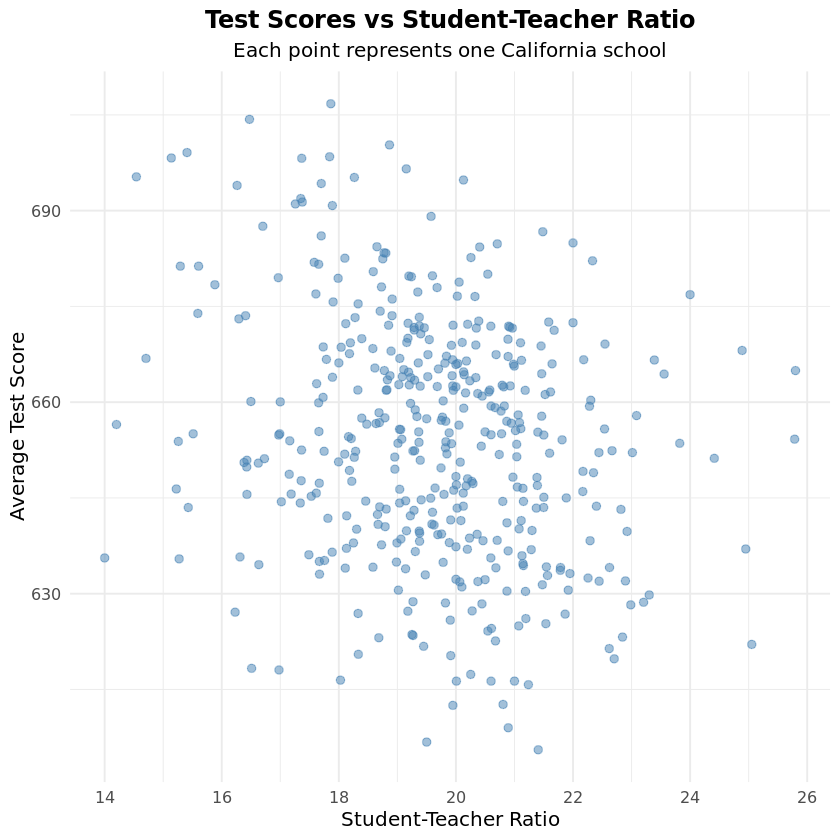

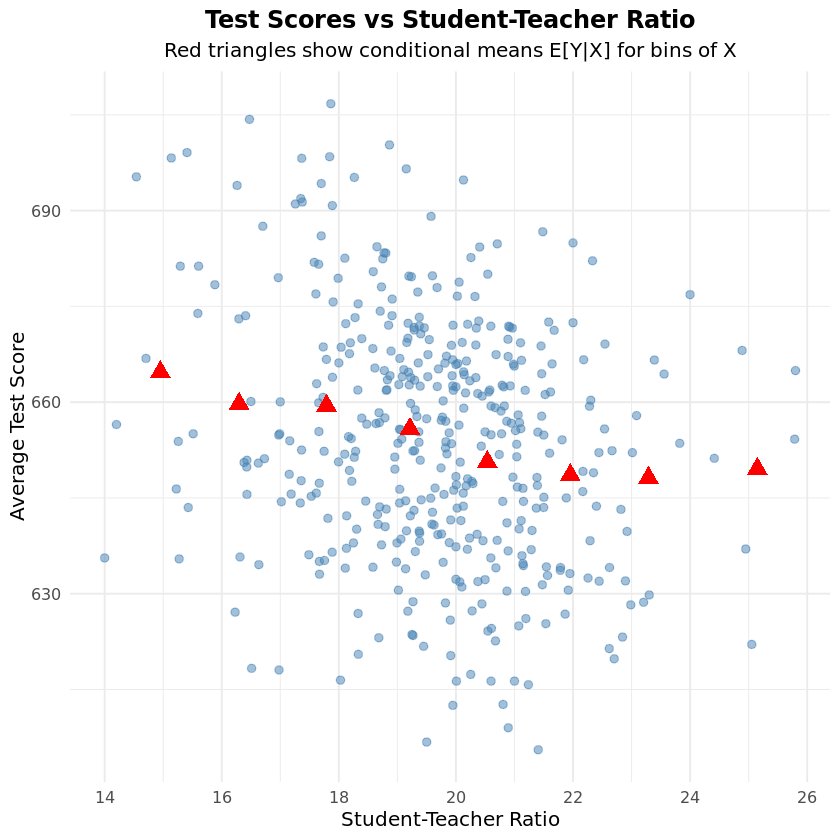

In [37]:
# Create a scatter plot to show the relationship
p1 <- ggplot(caschool, aes(x = str, y = testscr)) +
  geom_point(alpha = 0.5, color = "steelblue", size = 2) +
  labs(
    title = "Test Scores vs Student-Teacher Ratio",
    subtitle = "Each point represents one California school",
    x = "Student-Teacher Ratio",
    y = "Average Test Score"
  ) +
  theme(plot.title = element_text(hjust = 0.5, face = "bold"),
        plot.subtitle = element_text(hjust = 0.5))

print(p1)

# Add binned means to show E[Y|X]
# This helps visualize the conditional expectation function
caschool$str_bin <- cut(caschool$str, breaks = 8)
bin_means <- caschool %>%
  group_by(str_bin) %>%
  summarise(
    mean_str = mean(str),
    mean_testscr = mean(testscr),
    n = n()
  )

p2 <- p1 +
  geom_point(data = bin_means, 
             aes(x = mean_str, y = mean_testscr),
             color = "red", size = 4, shape = 17) +
  labs(subtitle = "Red triangles show conditional means E[Y|X] for bins of X")

print(p2)

# PART 3: OLS ESTIMATION - MANUAL CALCULATION


In [38]:
cat("\n", strrep("=", 60), "\n")
cat("PART 3: Manual OLS Calculation\n")
cat(strrep("=", 60), "\n\n")

# Extract variables
Y <- caschool$testscr
X <- caschool$str
n <- length(Y)

# Calculate means
Y_bar <- mean(Y)
X_bar <- mean(X)

cat("Sample means:\n")
cat(sprintf("Mean test score (Ȳ): %.2f\n", Y_bar))
cat(sprintf("Mean student-teacher ratio (X̄): %.2f\n", X_bar))

# Calculate OLS estimators manually 
# β̂₁ = Σ(Xᵢ - X̄)(Yᵢ - Ȳ) / Σ(Xᵢ - X̄)²
numerator <- sum((X - X_bar) * (Y - Y_bar))
denominator <- sum((X - X_bar)^2)
beta1_hat <- numerator / denominator

# β̂₀ = Ȳ - β̂₁X̄
beta0_hat <- Y_bar - beta1_hat * X_bar

cat("\nOLS Estimates (Manual Calculation):\n")
cat(sprintf("β̂₀ (Intercept): %.3f\n", beta0_hat))
cat(sprintf("β̂₁ (Slope): %.3f\n", beta1_hat))

# Interpretation
cat("\nInterpretation:\n")
cat(sprintf("• For each additional student per teacher, test scores decrease by %.2f points\n", 
            abs(beta1_hat)))
cat(sprintf("• A school with STR = 0 would have predicted score of %.1f\n", beta0_hat))
cat("  (Note: STR = 0 is outside our data range, so this isn't meaningful)\n")



PART 3: Manual OLS Calculation

Sample means:
Mean test score (Ȳ): 654.16
Mean student-teacher ratio (X̄): 19.64

OLS Estimates (Manual Calculation):
β̂₀ (Intercept): 698.933
β̂₁ (Slope): -2.280

Interpretation:
• For each additional student per teacher, test scores decrease by 2.28 points
• A school with STR = 0 would have predicted score of 698.9
  (Note: STR = 0 is outside our data range, so this isn't meaningful)


# PART 4: OLS ESTIMATION - USING lm() FUNCTION


In [39]:
cat("\n", strrep("=", 60), "\n")
cat("PART 4: OLS Using R's lm() Function\n")
cat(strrep("=", 60), "\n\n")

# Estimate the regression model
model <- lm(testscr ~ str, data = caschool)

# Display results
print(summary(model))

# Extract coefficients
coef_model <- coef(model)
cat("\nVerification: Manual calculation matches lm():\n")
cat(sprintf("Manual β̂₀ = %.3f, lm() β̂₀ = %.3f\n", beta0_hat, coef_model[1]))
cat(sprintf("Manual β̂₁ = %.3f, lm() β̂₁ = %.3f\n", beta1_hat, coef_model[2]))



PART 4: OLS Using R's lm() Function


Call:
lm(formula = testscr ~ str, data = caschool)

Residuals:
    Min      1Q  Median      3Q     Max 
-47.727 -14.251   0.483  12.822  48.540 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 698.9330     9.4675  73.825  < 2e-16 ***
str          -2.2798     0.4798  -4.751 2.78e-06 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 18.58 on 418 degrees of freedom
Multiple R-squared:  0.05124,	Adjusted R-squared:  0.04897 
F-statistic: 22.58 on 1 and 418 DF,  p-value: 2.783e-06


Verification: Manual calculation matches lm():
Manual β̂₀ = 698.933, lm() β̂₀ = 698.933
Manual β̂₁ = -2.280, lm() β̂₁ = -2.280


# PART 5: FITTED VALUES AND RESIDUALS

In [40]:
cat("\n", strrep("=", 60), "\n")
cat("PART 5: Understanding Fitted Values and Residuals\n")
cat(strrep("=", 60), "\n\n")

# Calculate fitted values and residuals
caschool$fitted <- beta0_hat + beta1_hat * caschool$str
caschool$residuals <- caschool$testscr - caschool$fitted

# See examples: 
example_strs <- c(15, 20, 25)
cat("Predicted test scores for specific STR values:\n")
for (str_val in example_strs) {
  pred_score <- beta0_hat + beta1_hat * str_val
  cat(sprintf("STR = %d: Predicted score = %.2f\n", str_val, pred_score))
}

# Find actual schools close to these STR values for comparison
cat("\nActual vs Predicted for schools near these STR values:\n")
for (str_val in example_strs) {
  close_school <- caschool[which.min(abs(caschool$str - str_val)), ]
  cat(sprintf("School with STR = %.2f:\n", close_school$str))
  cat(sprintf("  Actual score: %.2f\n", close_school$testscr))
  cat(sprintf("  Predicted score: %.2f\n", close_school$fitted))
  cat(sprintf("  Residual (Ûᵢ): %.2f\n\n", close_school$residuals))
}


PART 5: Understanding Fitted Values and Residuals

Predicted test scores for specific STR values:
STR = 15: Predicted score = 664.74
STR = 20: Predicted score = 653.34
STR = 25: Predicted score = 641.94

Actual vs Predicted for schools near these STR values:
School with STR = 15.14:
  Actual score: 698.25
  Predicted score: 664.42
  Residual (Ûᵢ): 33.83

School with STR = 20.00:
  Actual score: 632.25
  Predicted score: 653.34
  Residual (Ûᵢ): -21.09

School with STR = 24.95:
  Actual score: 637.00
  Predicted score: 642.05
  Residual (Ûᵢ): -5.05



# PART 6: VISUALIZING THE REGRESSION LINE

`geom_smooth()` using formula = 'y ~ x'


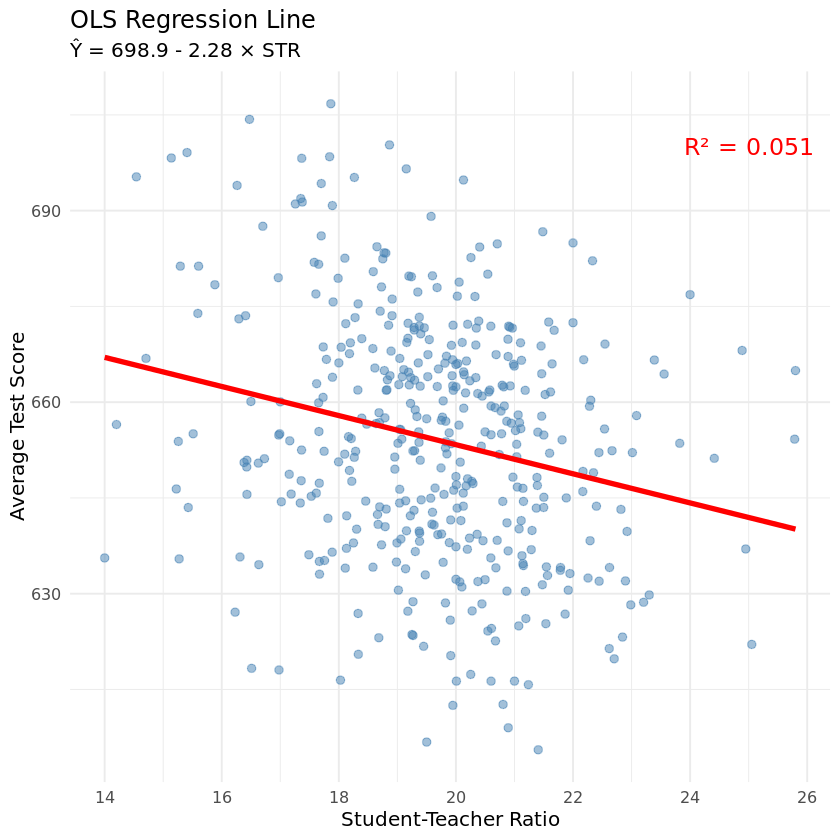

In [41]:
# Plot with regression line
p3 <- ggplot(caschool, aes(x = str, y = testscr)) +
  geom_point(alpha = 0.5, color = "steelblue", size = 2) +
  geom_smooth(method = "lm", se = FALSE, color = "red", linewidth = 1.5) +
  labs(
    title = "OLS Regression Line",
    subtitle = sprintf("Ŷ = %.1f - %.2f × STR", beta0_hat, abs(beta1_hat)),
    x = "Student-Teacher Ratio",
    y = "Average Test Score"
  ) +
  annotate("text", x = 25, y = 700, 
           label = sprintf("R² = %.3f", summary(model)$r.squared),
           size = 5, color = "red")

print(p3)

# PART 7: PROPERTIES OF OLS RESIDUALS



PART 7: Properties of OLS Residuals

Property 1: Mean of residuals =  2.053128e-14 
(Should be approximately 0)

Property 2: Correlation(X, Û) =  1.20301e-16 
(Should be approximately 0)

Property 3: Covariance between X and residuals
  Covariance formula: Σ((Xᵢ - X̄) × (Ûᵢ - Ū)) =  1.805139e-12 
  (Should be approximately 0)

  Note: Since Ū ≈ 0, we have Σ((Xᵢ - X̄) × Ûᵢ) ≈  1.756761e-12 



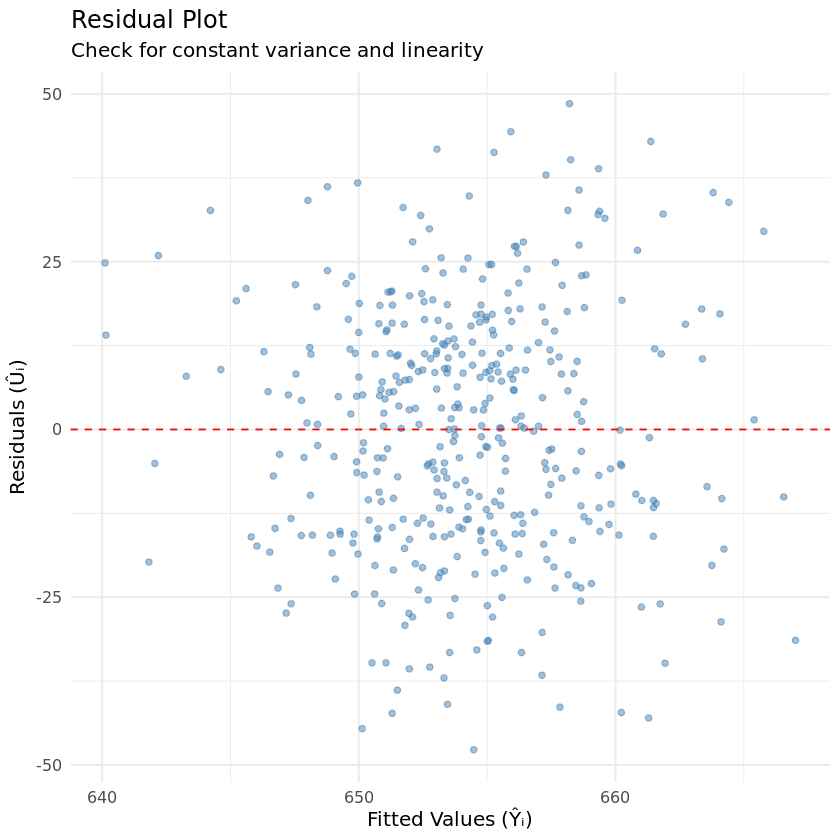

In [42]:
cat("\n", strrep("=", 60), "\n")
cat("PART 7: Properties of OLS Residuals\n")
cat(strrep("=", 60), "\n\n")

# Property 1: Mean of residuals is zero
cat("Property 1: Mean of residuals = ", mean(caschool$residuals), "\n")
cat("(Should be approximately 0)\n\n")

# Property 2: Correlation between X and residuals is zero
cat("Property 2: Correlation(X, Û) = ", cor(caschool$str, caschool$residuals), "\n")
cat("(Should be approximately 0)\n\n")

# Property 3: Covariance between X and residuals is zero
cat("Property 3: Covariance between X and residuals\n")
cat("  Covariance formula: Σ((Xᵢ - X̄) × (Ûᵢ - Ū)) = ", 
    sum((caschool$str - mean(caschool$str)) * (caschool$residuals - mean(caschool$residuals))), "\n")
cat("  (Should be approximately 0)\n\n")

# Note: Since mean(residuals) ≈ 0, the covariance formula simplifies
cat("  Note: Since Ū ≈ 0, we have Σ((Xᵢ - X̄) × Ûᵢ) ≈ ", 
    sum((caschool$str - mean(caschool$str)) * caschool$residuals), "\n\n")

# Residual plot for checking assumptions
p5 <- ggplot(caschool, aes(x = fitted, y = residuals)) +
  geom_point(alpha = 0.5, color = "steelblue") +
  geom_hline(yintercept = 0, linetype = "dashed", color = "red") +
  labs(
    title = "Residual Plot",
    subtitle = "Check for constant variance and linearity",
    x = "Fitted Values (Ŷᵢ)",
    y = "Residuals (Ûᵢ)"
  )
print(p5)

# PART 8: COMPARING DIFFERENT FUNCTIONAL FORMS


PART 8: Why Linear? Comparing Functional Forms

Model Comparison (R²):
Linear:     R² = 0.0512
Quadratic:  R² = 0.0523
Logarithmic: R² = 0.0517


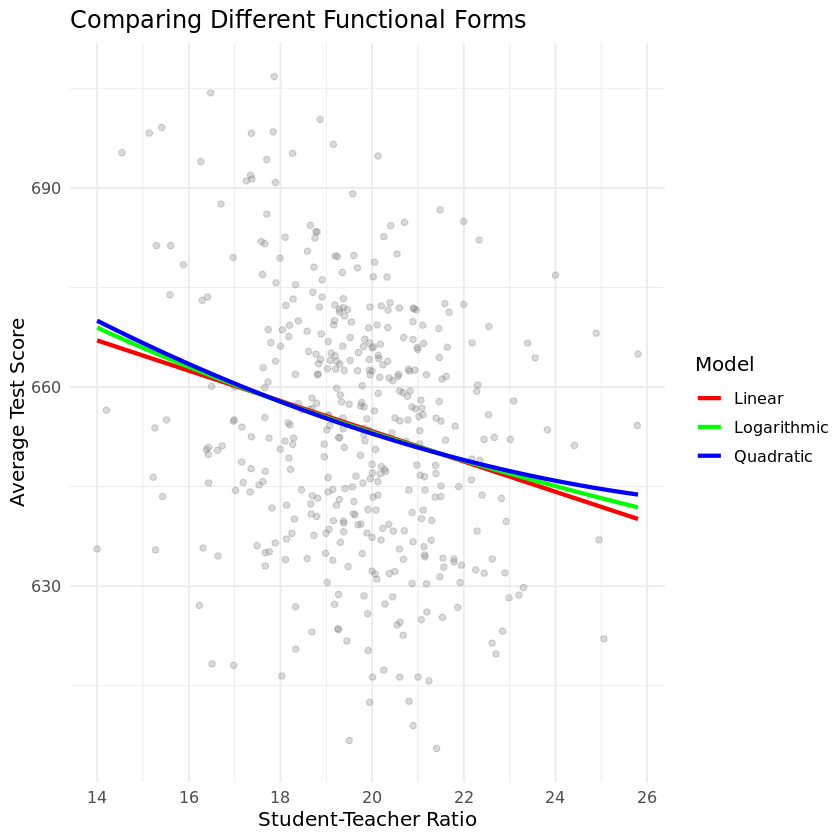

In [43]:
cat("\n", strrep("=", 60), "\n")
cat("PART 8: Why Linear? Comparing Functional Forms\n")
cat(strrep("=", 60), "\n\n")

# Estimate different models 
model_linear <- lm(testscr ~ str, data = caschool)
model_quad <- lm(testscr ~ str + I(str^2), data = caschool)
model_log <- lm(testscr ~ log(str), data = caschool)

# Compare R-squared
cat("Model Comparison (R²):\n")
cat(sprintf("Linear:     R² = %.4f\n", summary(model_linear)$r.squared))
cat(sprintf("Quadratic:  R² = %.4f\n", summary(model_quad)$r.squared))
cat(sprintf("Logarithmic: R² = %.4f\n", summary(model_log)$r.squared))

# Visualize all three
str_range <- seq(min(caschool$str), max(caschool$str), length.out = 100)
pred_linear <- predict(model_linear, newdata = data.frame(str = str_range))
pred_quad <- predict(model_quad, newdata = data.frame(str = str_range))
pred_log <- predict(model_log, newdata = data.frame(str = str_range))

plot_data <- data.frame(
  str = rep(str_range, 3),
  testscr = c(pred_linear, pred_quad, pred_log),
  Model = rep(c("Linear", "Quadratic", "Logarithmic"), each = 100)
)

p6 <- ggplot() +
  geom_point(data = caschool, aes(x = str, y = testscr), 
             alpha = 0.3, color = "gray50") +
  geom_line(data = plot_data, aes(x = str, y = testscr, color = Model),
            linewidth = 1.2) +
  scale_color_manual(values = c("Linear" = "red", 
                                "Quadratic" = "blue", 
                                "Logarithmic" = "green")) +
  labs(
    title = "Comparing Different Functional Forms",
    x = "Student-Teacher Ratio",
    y = "Average Test Score"
  )

print(p6)

# PART 9: UNDERSTANDING VARIATION AND R-SQUARED

In [44]:
cat("\n", strrep("=", 60), "\n")
cat("PART 9: Decomposing Variation\n")
cat(strrep("=", 60), "\n\n")

# Calculate sum of squares
TSS <- sum((Y - Y_bar)^2)  # Total Sum of Squares
ESS <- sum((caschool$fitted - Y_bar)^2)  # Explained Sum of Squares
RSS <- sum(caschool$residuals^2)  # Residual Sum of Squares

cat("Variation Decomposition:\n")
cat(sprintf("Total SS (TSS):     %.1f\n", TSS))
cat(sprintf("Explained SS (ESS): %.1f\n", ESS))
cat(sprintf("Residual SS (RSS):  %.1f\n", RSS))
cat(sprintf("TSS = ESS + RSS:    %.1f = %.1f\n\n", TSS, ESS + RSS))

# Calculate R-squared manually
R2_manual <- ESS / TSS
cat(sprintf("R² = ESS/TSS = %.4f\n", R2_manual))
cat(sprintf("Interpretation: %.1f%% of variation in test scores is explained by STR\n", 
            R2_manual * 100))


PART 9: Decomposing Variation

Variation Decomposition:
Total SS (TSS):     152109.6
Explained SS (ESS): 7794.1
Residual SS (RSS):  144315.5
TSS = ESS + RSS:    152109.6 = 152109.6

R² = ESS/TSS = 0.0512
Interpretation: 5.1% of variation in test scores is explained by STR
